In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['CUDA_VISIBLE_DEVICES'] = "0"

import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

In [7]:
import os
import sys
sys.path.append('../data_preprocessing')

In [ ]:
# Now, you can import the module
import RNN_preprocessing_sep_chain as rp

In [10]:
import psutil
print(psutil.virtual_memory())  # Shows memory usage

svmem(total=16649175040, available=6923857920, percent=58.4, used=8903147520, free=5199601664, active=2132914176, inactive=8620539904, buffers=61767680, cached=2484658176, shared=469372928, slab=337747968)


In [11]:
import gc
gc.collect()

2954

In [12]:
print(psutil.virtual_memory()) 

svmem(total=16649175040, available=6888677376, percent=58.6, used=8923185152, free=5164437504, active=2132971520, inactive=8618455040, buffers=61825024, cached=2499727360, shared=484515840, slab=337952768)


In [ ]:
X1_train = rp.X1_seq_train 
X1_test = rp.X1_seq_test 
y1_train = rp.y1_seq_train 
y1_test = rp.y1_seq_test
X2_train = rp.X2_seq_train 
X2_test = rp.X2_seq_test 
y2_train = rp.y2_seq_train 
y2_test = rp.y2_seq_test

AttributeError: module 'RNN_preprocessing' has no attribute 'X1'

In [ ]:
# Clear memory associated with the module
import sys
del rp
if 'RNN_preprocessing_sep_chain' in sys.modules:
    del sys.modules['RNN_preprocessing_sep_chain']

# Clear memory from global variables if needed
import gc
gc.collect()

6

In [ ]:
X1_seq_train, X1_seq_val, y1_seq_train, y1_seq_val = train_test_split(X1_train, y1_train, test_size=0.2, random_state=0)

In [ ]:
X2_seq_train, X2_seq_val, y2_seq_train, y2_seq_val = train_test_split(X2_train, y2_train, test_size=0.2, random_state=0)

NameError: name 'X2' is not defined

In [ ]:
X1_train = X1_seq_train
X1_val = X1_seq_val
y1_train = y1_seq_train
y1_val = y1_seq_val 
X2_train = X2_seq_train
X2_val = X2_seq_val
y2_train = y2_seq_train
y2_val = y2_seq_val 

In [ ]:
# Delete the training/test split variables after they are used
del X1_seq_train, X1_seq_val, y1_seq_train, y1_seq_val, X2_seq_train, X2_seq_val, y2_seq_train, y2_seq_val

# Force garbage collection
gc.collect()

LSTM

In [ ]:
#Long Short Term Memory model
def model_lstm (input_shape, output_shape):
    model = keras.Sequential(
        [
            layers.LSTM(32, input_shape=input_shape, activation="tanh", return_sequences=True),
            layers.LSTM(16, activation="tanh", return_sequences=True),
            layers.Dense(8, activation="relu"),
            layers.Dense(output_shape, activation="softmax"),
        ]
    )
    model.compile(loss="categorical_crossentropy", optimizer = "adam", metrics=['accuracy'])
    return model

In [ ]:
seq_length=10

In [ ]:
#Model for the BiPo 214 chain
model1 = model_lstm((seq_length, X1_train.shape[2]), y1_train.shape[2])

model1.summary()

2025-01-24 13:32:19.119407: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 10, 64)            18176     
                                                                 
 lstm_1 (LSTM)               (None, 10, 32)            12416     
                                                                 
 dense (Dense)               (None, 10, 16)            528       
                                                                 
 dense_1 (Dense)             (None, 10, 4)             68        
                                                                 
Total params: 31188 (121.83 KB)
Trainable params: 31188 (121.83 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [10]:
#Model for the BiPo 212 chain
model2 = model_lstm((rp.seq_length, X2_train.shape[2]), y2_train.shape[2])
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 10, 64)            18176     
                                                                 
 lstm_3 (LSTM)               (None, 10, 32)            12416     
                                                                 
 dense_2 (Dense)             (None, 10, 16)            528       
                                                                 
 dense_3 (Dense)             (None, 10, 6)             102       
                                                                 
Total params: 31222 (121.96 KB)
Trainable params: 31222 (121.96 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [11]:
#callback for reducing the learning rate and stopping early in case the loss function hits a plateau
callbacks = [
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, verbose=1, min_lr=1E-6),
    tf.keras.callbacks.EarlyStopping(patience=10, verbose=1, baseline=None, restore_best_weights=True)
]

In [12]:
# Clear any previous session
tf.keras.backend.clear_session()
gc.collect()


12747

In [24]:
# Train model 1
history1 = model1.fit(X1_train, y1_train, epochs=200, batch_size=256, verbose=2,
                      validation_data=(X1_val, y1_val),
                      callbacks=callbacks)

Epoch 1/200
2702/2702 - 140s - loss: 0.3601 - accuracy: 0.8471 - val_loss: 0.2805 - val_accuracy: 0.8888 - lr: 0.0010 - 140s/epoch - 52ms/step
Epoch 2/200
2702/2702 - 125s - loss: 0.2681 - accuracy: 0.8943 - val_loss: 0.2633 - val_accuracy: 0.8958 - lr: 0.0010 - 125s/epoch - 46ms/step
Epoch 3/200
2702/2702 - 125s - loss: 0.2558 - accuracy: 0.9002 - val_loss: 0.2519 - val_accuracy: 0.9019 - lr: 0.0010 - 125s/epoch - 46ms/step
Epoch 4/200
2702/2702 - 125s - loss: 0.2497 - accuracy: 0.9030 - val_loss: 0.2479 - val_accuracy: 0.9039 - lr: 0.0010 - 125s/epoch - 46ms/step
Epoch 5/200
2702/2702 - 125s - loss: 0.2479 - accuracy: 0.9037 - val_loss: 0.2474 - val_accuracy: 0.9037 - lr: 0.0010 - 125s/epoch - 46ms/step
Epoch 6/200
2702/2702 - 125s - loss: 0.2468 - accuracy: 0.9043 - val_loss: 0.2480 - val_accuracy: 0.9032 - lr: 0.0010 - 125s/epoch - 46ms/step
Epoch 7/200
2702/2702 - 125s - loss: 0.2462 - accuracy: 0.9045 - val_loss: 0.2453 - val_accuracy: 0.9049 - lr: 0.0010 - 125s/epoch - 46ms/step

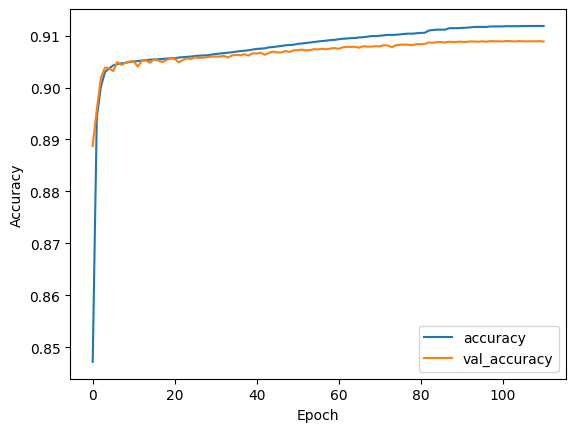

In [25]:
#plotting the accuracy of the first model
plt.plot(history1.history['accuracy'], label='accuracy')
plt.plot(history1.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

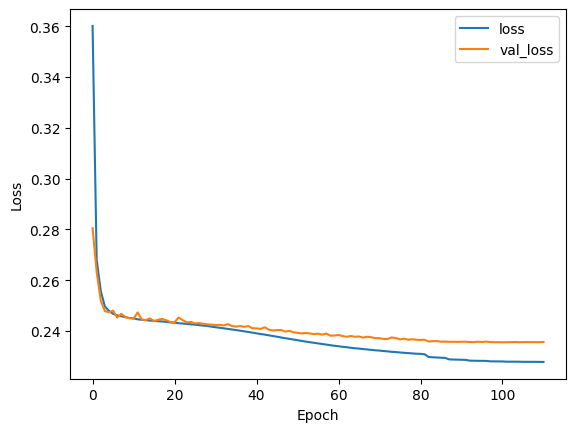

In [26]:
#plotting the loss over epoch for the first model
plt.plot(history1.history['loss'], label='loss')
plt.plot(history1.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [13]:
#save the first trained model
model1.save('model_lstm_214.h5')

/home/pipc06/.local/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
# Train model 2
history2 = model2.fit(X2_train, y2_train, epochs=200, batch_size=256, verbose=2,
                      validation_data=(X2_val, y2_val),
                      callbacks=callbacks)

Epoch 1/200
16039/16039 - 781s - loss: 0.4869 - accuracy: 0.7867 - val_loss: 0.4399 - val_accuracy: 0.8129 - lr: 0.0010 - 781s/epoch - 49ms/step
Epoch 2/200
16039/16039 - 581s - loss: 0.4419 - accuracy: 0.8120 - val_loss: 0.4398 - val_accuracy: 0.8132 - lr: 0.0010 - 581s/epoch - 36ms/step
Epoch 3/200
16039/16039 - 555s - loss: 0.4400 - accuracy: 0.8129 - val_loss: 0.4455 - val_accuracy: 0.8089 - lr: 0.0010 - 555s/epoch - 35ms/step
Epoch 4/200
16039/16039 - 558s - loss: 0.4389 - accuracy: 0.8136 - val_loss: 0.4392 - val_accuracy: 0.8133 - lr: 0.0010 - 558s/epoch - 35ms/step
Epoch 5/200
16039/16039 - 556s - loss: 0.4383 - accuracy: 0.8139 - val_loss: 0.4372 - val_accuracy: 0.8148 - lr: 0.0010 - 556s/epoch - 35ms/step
Epoch 6/200
16039/16039 - 558s - loss: 0.4378 - accuracy: 0.8142 - val_loss: 0.4378 - val_accuracy: 0.8147 - lr: 0.0010 - 558s/epoch - 35ms/step
Epoch 7/200
16039/16039 - 557s - loss: 0.4375 - accuracy: 0.8143 - val_loss: 0.4399 - val_accuracy: 0.8134 - lr: 0.0010 - 557s/epo

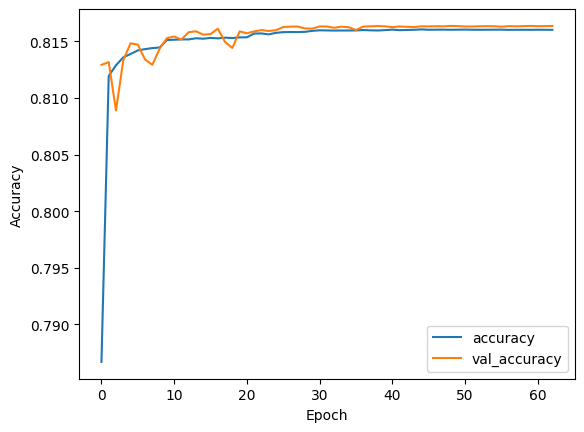

In [7]:
#plotting the accuracy of the second model
plt.plot(history2.history['accuracy'], label='accuracy')
plt.plot(history2.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

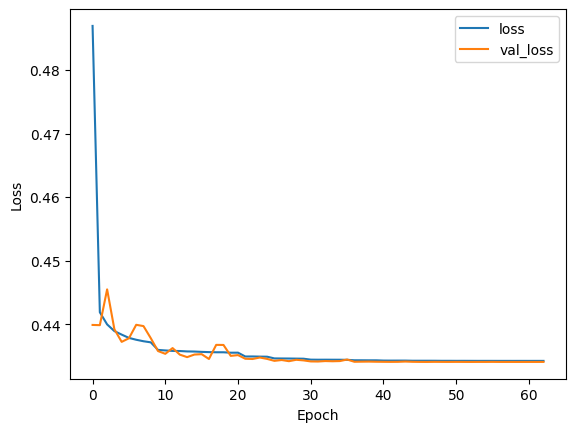

In [8]:
#plotting the loss over epoch for the second model
plt.plot(history2.history['loss'], label='loss')
plt.plot(history2.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [12]:
#save the second trained model
model2.save('model_lstm_212.h5')

/home/pipc06/.local/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


: 